In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


PRAKTIKUM 6.2: INVERSE FILTER VS WIENER FILTER


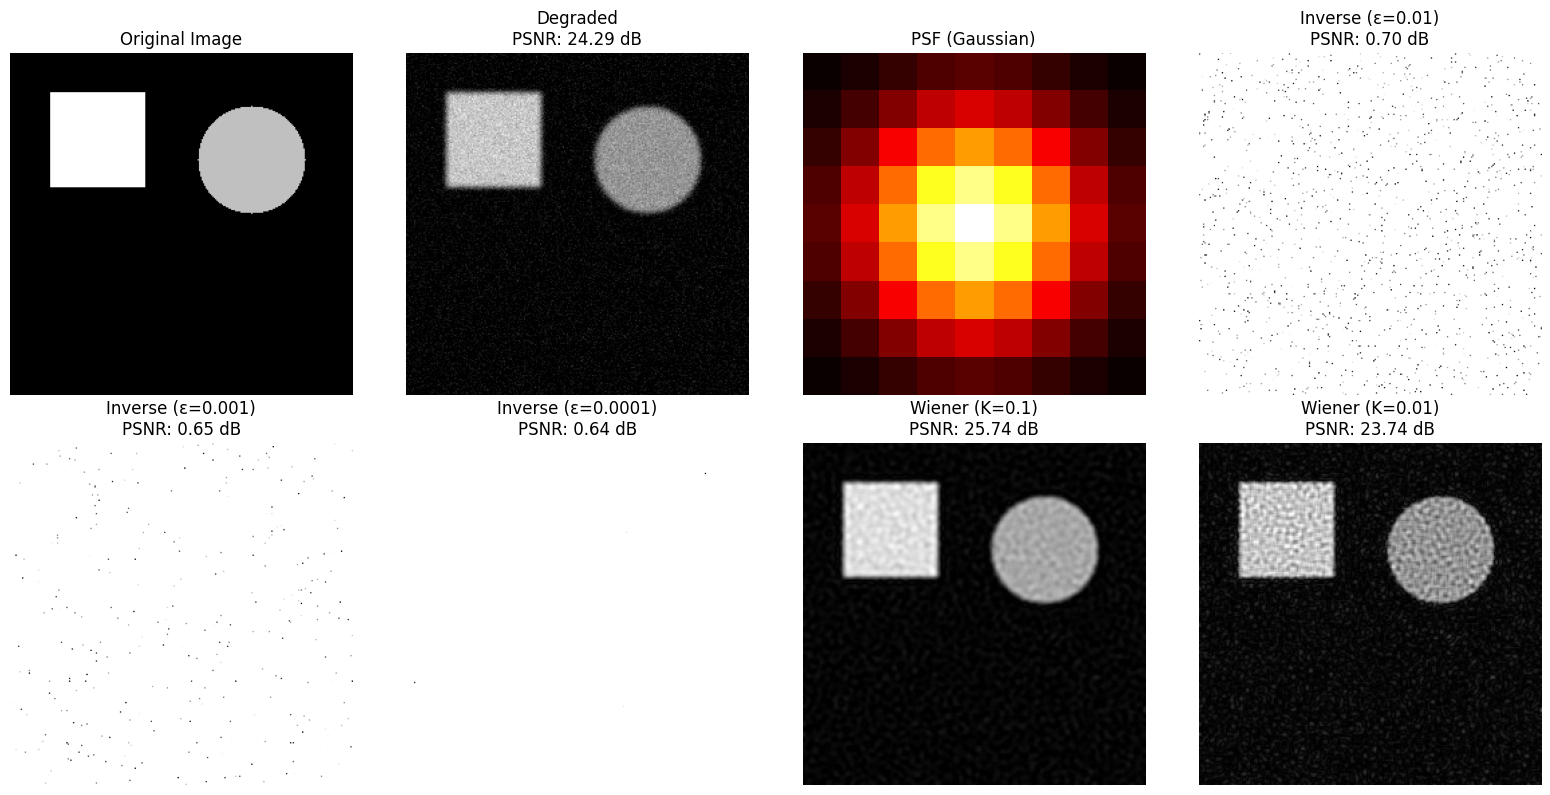


RESTORATION PERFORMANCE COMPARISON
----------------------------------------------------------------------
Method               PSNR (dB)    Improvement (dB) MSE         
----------------------------------------------------------------------
Inverse (ε=0.01)     0.70         -23.59          55286.82    
Inverse (ε=0.001)    0.65         -23.64          55947.10    
Inverse (ε=0.0001)   0.64         -23.65          56113.31    
Wiener (K=0.1)       25.74        1.45            173.27      
Wiener (K=0.01)      23.74        -0.55           274.54      
Wiener (K=0.001)     13.41        -10.89          2966.85     

FREQUENCY DOMAIN ANALYSIS
----------------------------------------


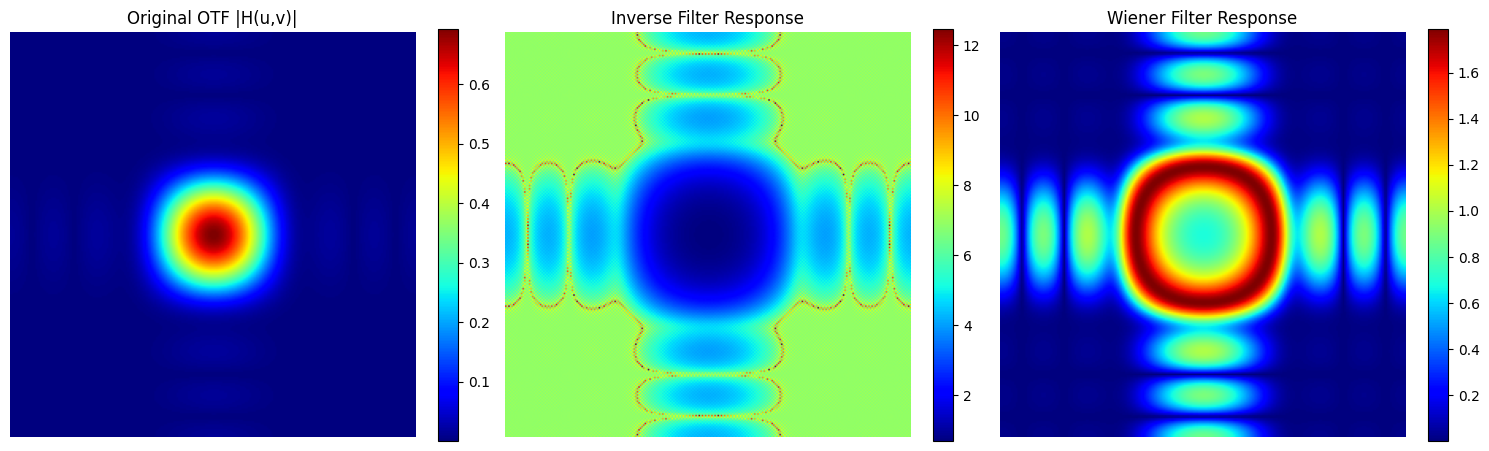

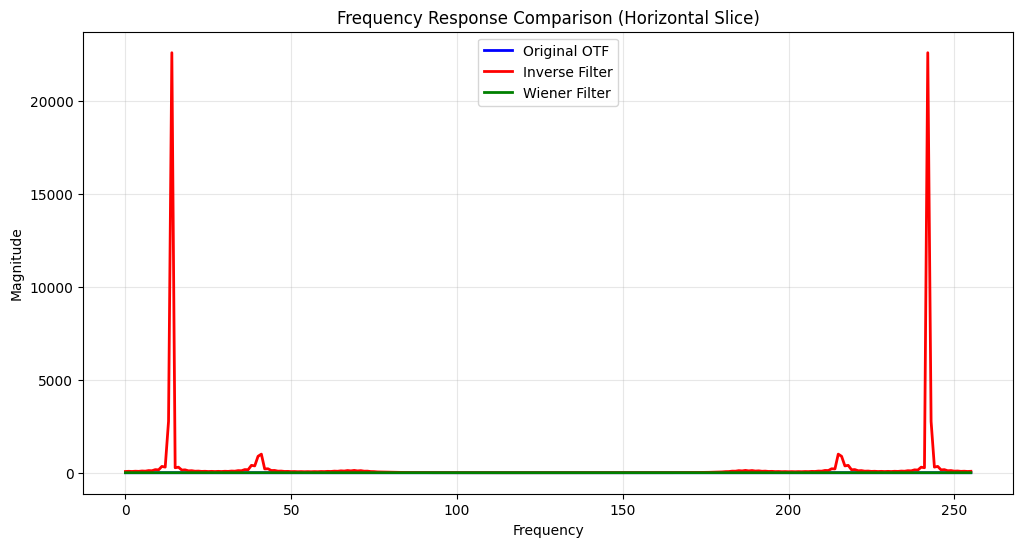

In [ ]:
def praktikum_6_2():
    """
    Perbandingan Inverse Filter dan Wiener Filter untuk restorasi citra
    """
    print("\nPRAKTIKUM 6.2: INVERSE FILTER VS WIENER FILTER")
    print("=" * 50)

    # Buat citra terdegradasi dengan blur dan noise
    def create_degraded_image():
        """Create image degraded with blur and noise"""
        # Create test pattern
        img = np.zeros((256, 256), dtype=np.uint8)
        cv2.rectangle(img, (30, 30), (100, 100), 200, -1)
        cv2.circle(img, (180, 80), 40, 150, -1)

        # Add Gaussian blur
        blurred = cv2.GaussianBlur(img, (9, 9), 2)

        # Add Gaussian noise
        noise = np.random.normal(0, 15, blurred.shape)
        degraded = np.clip(blurred + noise, 0, 255)

        return img, degraded.astype(np.uint8)

    # Implementasi filter restorasi
    def inverse_filter(degraded, psf, epsilon=1e-3):
        """Inverse filtering with regularization"""
        # Padding untuk menghindari boundary effects
        pad_size = psf.shape[0] // 2
        padded = cv2.copyMakeBorder(degraded, pad_size, pad_size,
                                   pad_size, pad_size, cv2.BORDER_REFLECT)

        # Transform ke domain frekuensi
        G = np.fft.fft2(padded.astype(float))

        # Buat PSF dengan size yang sama
        psf_padded = np.zeros_like(padded, dtype=float)
        psf_center_y, psf_center_x = psf.shape[0]//2, psf.shape[1]//2
        pad_center_y, pad_center_x = padded.shape[0]//2, padded.shape[1]//2

        y_start = pad_center_y - psf_center_y
        x_start = pad_center_x - psf_center_x
        psf_padded[y_start:y_start+psf.shape[0], x_start:x_start+psf.shape[1]] = psf

        # Shift PSF untuk centering
        psf_padded = np.fft.ifftshift(psf_padded)

        # Compute OTF
        H = np.fft.fft2(psf_padded)

        # Regularized inverse filter
        H_reg = H + epsilon

        # Apply inverse filter
        F_hat = G / H_reg

        # Inverse transform
        restored_padded = np.abs(np.fft.ifft2(F_hat))

        # Remove padding
        restored = restored_padded[pad_size:-pad_size, pad_size:-pad_size]

        return np.clip(restored, 0, 255).astype(np.uint8)

    def wiener_filter(degraded, psf, K=0.01):
        """Wiener filter implementation"""
        # Padding
        pad_size = psf.shape[0] // 2
        padded = cv2.copyMakeBorder(degraded, pad_size, pad_size,
                                   pad_size, pad_size, cv2.BORDER_REFLECT)

        # Transform ke domain frekuensi
        G = np.fft.fft2(padded.astype(float))

        # Buat PSF dengan size yang sama
        psf_padded = np.zeros_like(padded, dtype=float)
        psf_center_y, psf_center_x = psf.shape[0]//2, psf.shape[1]//2
        pad_center_y, pad_center_x = padded.shape[0]//2, padded.shape[1]//2

        y_start = pad_center_y - psf_center_y
        x_start = pad_center_x - psf_center_x
        psf_padded[y_start:y_start+psf.shape[0], x_start:x_start+psf.shape[1]] = psf

        # Shift PSF
        psf_padded = np.fft.ifftshift(psf_padded)

        # Compute OTF
        H = np.fft.fft2(psf_padded)
        H_conj = np.conj(H)
        H_abs_sq = np.abs(H) ** 2

        # Wiener filter
        W = H_conj / (H_abs_sq + K)

        # Apply filter
        F_hat = G * W

        # Inverse transform
        restored_padded = np.abs(np.fft.ifft2(F_hat))

        # Remove padding
        restored = restored_padded[pad_size:-pad_size, pad_size:-pad_size]

        return np.clip(restored, 0, 255).astype(np.uint8)

    # Generate PSF (Gaussian blur kernel)
    def create_gaussian_psf(size=9, sigma=2):
        """Create Gaussian PSF"""
        psf = np.zeros((size, size))
        center = size // 2

        for i in range(size):
            for j in range(size):
                x = i - center
                y = j - center
                psf[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2))

        psf = psf / np.sum(psf)
        return psf

    # Create test data
    original, degraded = create_degraded_image()
    psf = create_gaussian_psf(9, 2)

    # Apply different restoration filters dengan berbagai parameter
    restorations = {}

    # Inverse filter dengan berbagai epsilon
    for eps in [1e-2, 1e-3, 1e-4]:
        restored = inverse_filter(degraded, psf, epsilon=eps)
        restorations[f'Inverse (ε={eps})'] = restored

    # Wiener filter dengan berbagai K
    for K in [0.1, 0.01, 0.001]:
        restored = wiener_filter(degraded, psf, K=K)
        restorations[f'Wiener (K={K})'] = restored

    # Visualisasi hasil
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    # Original dan degraded
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(degraded, cmap='gray')

    # Calculate PSNR untuk degraded
    mse_degraded = np.mean((original.astype(float) - degraded.astype(float)) ** 2)
    psnr_degraded = 10 * np.log10(255**2 / mse_degraded)

    axes[1].set_title(f'Degraded\nPSNR: {psnr_degraded:.2f} dB')
    axes[1].axis('off')

    # Display PSF
    axes[2].imshow(psf, cmap='hot')
    axes[2].set_title('PSF (Gaussian)')
    axes[2].axis('off')

    # Display restoration results
    results_list = list(restorations.items())
    for idx in range(5):
        title, restored = results_list[idx]

        # Calculate PSNR
        mse = np.mean((original.astype(float) - restored.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / mse)

        axes[idx+3].imshow(restored, cmap='gray')
        axes[idx+3].set_title(f'{title}\nPSNR: {psnr:.2f} dB')
        axes[idx+3].axis('off')

    plt.tight_layout()
    plt.show()

    # Quantitative comparison
    print("\nRESTORATION PERFORMANCE COMPARISON")
    print("-" * 70)
    print(f"{'Method':<20} {'PSNR (dB)':<12} {'Improvement (dB)':<15} {'MSE':<12}")
    print("-" * 70)

    baseline_psnr = psnr_degraded

    for title, restored in restorations.items():
        mse = np.mean((original.astype(float) - restored.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / mse)
        improvement = psnr - baseline_psnr

        print(f"{title:<20} {psnr:<12.2f} {improvement:<15.2f} {mse:<12.2f}")

    # Frequency domain analysis
    print("\nFREQUENCY DOMAIN ANALYSIS")
    print("-" * 40)

    # Analyze frequency response of filters
    def analyze_frequency_response(psf, epsilon=1e-3, K=0.01):
        """Analyze frequency response of filters"""
        size = 256
        psf_padded = np.zeros((size, size))
        center = size // 2
        psf_center = psf.shape[0] // 2

        # Place PSF in center
        y_start = center - psf_center
        x_start = center - psf_center
        psf_padded[y_start:y_start+psf.shape[0], x_start:x_start+psf.shape[1]] = psf

        # Compute OTF
        H = np.fft.fft2(psf_padded)
        H = np.fft.fftshift(H)

        # Inverse filter response
        H_inv = 1 / (H + epsilon)

        # Wiener filter response
        H_conj = np.conj(H)
        H_abs_sq = np.abs(H) ** 2
        H_wiener = H_conj / (H_abs_sq + K)

        return np.abs(H), np.abs(H_inv), np.abs(H_wiener)

    H, H_inv, H_wiener = analyze_frequency_response(psf)

    # Plot frequency responses
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original OTF
    im1 = axes[0].imshow(np.log(1 + np.abs(H)), cmap='jet')
    axes[0].set_title('Original OTF |H(u,v)|')
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0], fraction=0.046)

    # Inverse filter response
    im2 = axes[1].imshow(np.log(1 + np.abs(H_inv)), cmap='jet')
    axes[1].set_title('Inverse Filter Response')
    axes[1].axis('off')
    plt.colorbar(im2, ax=axes[1], fraction=0.046)

    # Wiener filter response
    im3 = axes[2].imshow(np.log(1 + np.abs(H_wiener)), cmap='jet')
    axes[2].set_title('Wiener Filter Response')
    axes[2].axis('off')
    plt.colorbar(im3, ax=axes[2], fraction=0.046)

    plt.tight_layout()
    plt.show()

    # Perbandingan cross-section
    center = 128
    H_slice = np.abs(H)[center, :]
    H_inv_slice = np.abs(H_inv)[center, :]
    H_wiener_slice = np.abs(H_wiener)[center, :]

    plt.figure(figsize=(12, 6))
    plt.plot(H_slice, 'b-', linewidth=2, label='Original OTF')
    plt.plot(H_inv_slice, 'r-', linewidth=2, label='Inverse Filter')
    plt.plot(H_wiener_slice, 'g-', linewidth=2, label='Wiener Filter')
    plt.title('Frequency Response Comparison (Horizontal Slice)')
    plt.xlabel('Frequency')
    plt.ylabel('Magnitude')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return original, degraded, restorations

original, degraded, restorations = praktikum_6_2()